#Mining the Relationship Between Music Listening and Mental Health (Interim report)
#CS4403 - Data Mining
#Jeremy Qiao #3753194
#24th Mar 2026

#Load this file into a pandas data frame in a Jupyter Notebook

Data Dictionary provided by [@catherinerasgaitis] for the Music and Mental Health Dataset. https://www.kaggle.com/datasets/catherinerasgaitis/mxmh-survey-results?resource=download

This dataset contains survey 736 participants exploring the relationship between music listening habits and mental health. It includes demographic information, music preferences, listening behavior, and self-reported mental health conditions such as anxiety, depression, and insomnia. The dataset is suitable for data analysis, classification, and clustering to identify patterns between music and mental wellness.

## Table of Contents:
•	Participant Information  
•	Music Listening Habits  
•	Mental Health Measures  
•	Additional Attributes  

## Participant Information:

### 1. Age  
Age of the participant

## Music Listening Habits:
What kind of muisc genre they like, how many hours they listen to music per day, what is the BPM of their muisc.

### 1. HoursPerDay  
Average number of hours the participant listens to music per day.

### 2. WhileWorking  
Whether the participant listens to music while working (Yes/No).

### 3. FavGenre  
The participant's favorite music genre (Rock, Pop, Classical, Hip-Hop, etc.).

### 4. Exploratory  
Whether the participant actively explores new music (Yes/No).

### 5. ForeignLanguages  
Whether the participant listens to music in foreign languages (Yes/No).

### 6. BPM  
Preferred beats per minute of music.

## Mental Health Measures:

### 1. Anxiety  
Self-reported anxiety level (scale 0-10).

### 2. Depression  
Self-reported depression level (scale 0-10).

### 3. Insomnia  
Self-reported insomnia level (scale 0-10).

### 4. OCD  
Self-reported OCD level (scale  0-10).



## MusicEffects:
Participant's perception of how music affects their mental health:

•	Improve  
•	No Effect  
•	Worsen  

Evidence of the impact of music listening habits on mental wellness can be found in this dataset. Using a combination of behavioural and psychological data makes it easier to find trends and build models that predict music's influence on anxiety, depression, insomnia.

In [30]:
#data handling
import pandas as pd
import numpy as np

#visualization
import seaborn as sns
import matplotlib.pyplot as plt

#LLM_ML
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#easy download
import gdown

#Download the dataset  and load the data

In [31]:

#load dataset
file_id = '1JG2XnjWLd6J1XI_feIwfUq_sCwbxiwj_'
url = f'https://drive.google.com/uc?id={file_id}'

gdown.download(url, 'MusicMental.csv', quiet=False)

df = pd.read_csv('MusicMental.csv')

df.head(10)

Downloading...
From: https://drive.google.com/uc?id=1JG2XnjWLd6J1XI_feIwfUq_sCwbxiwj_
To: /content/MusicMental.csv
100%|██████████| 173k/173k [00:00<00:00, 28.3MB/s]


,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.
5,8/27/2022 21:56:50,18.0,Spotify,5.0,Yes,Yes,Yes,Jazz,Yes,Yes,...,Very frequently,Very frequently,Very frequently,Never,8.0,8.0,7.0,7.0,Improve,I understand.
6,8/27/2022 22:00:29,18.0,YouTube Music,3.0,Yes,Yes,No,Video game music,Yes,Yes,...,Rarely,Never,Never,Sometimes,4.0,8.0,6.0,0.0,Improve,I understand.
7,8/27/2022 22:18:59,21.0,Spotify,1.0,Yes,No,No,K pop,Yes,Yes,...,Sometimes,Rarely,Never,Rarely,5.0,3.0,5.0,3.0,Improve,I understand.
8,8/27/2022 22:33:05,19.0,Spotify,6.0,Yes,No,No,Rock,No,No,...,Never,Never,Very frequently,Never,2.0,0.0,0.0,0.0,Improve,I understand.
9,8/27/2022 22:44:03,18.0,I do not use a streaming service.,1.0,Yes,No,No,R&B,Yes,Yes,...,Sometimes,Rarely,Sometimes,Sometimes,2.0,2.0,5.0,1.0,Improve,I understand.


Helping Jake saves his time for downloading data.

#Full data check to understand the dataset before modeling.

In [32]:
#preview
print("First 5 rows:")
display(df.head())

#column names
print("\nColumn names:")
print(df.columns.tolist())

#data quality
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=True)
}).sort_index()

print("\nSummary table:")
display(summary)

#check categorical columns (i will remove some of them later)
key_categorical_cols = [
    "Primary streaming service",
    "While working",
    "Instrumentalist",
    "Composer",
    "Fav genre",
    "Exploratory",
    "Foreign languages",
    "Music effects"
]

for col in key_categorical_cols:
    if col in df.columns:
        print(f"\nValue counts: {col}")
        print(df[col].value_counts(dropna=False))
print("\nNumeric summary statistics:")
display(df.describe())

#duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

#important numeric columns
important_numeric_cols = [
    "Age",
    "Hours per day",
    "BPM",
    "Anxiety",
    "Depression",
    "Insomnia",
    "OCD"
]

for col in important_numeric_cols:
    if col in df.columns:
        print(f"\nColumn: {col}")
        print("Min:", df[col].min())
        print("Max:", df[col].max())

First 5 rows:


,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.



Column names:
['Timestamp', 'Age', 'Primary streaming service', 'Hours per day', 'While working', 'Instrumentalist', 'Composer', 'Fav genre', 'Exploratory', 'Foreign languages', 'BPM', 'Frequency [Classical]', 'Frequency [Country]', 'Frequency [EDM]', 'Frequency [Folk]', 'Frequency [Gospel]', 'Frequency [Hip hop]', 'Frequency [Jazz]', 'Frequency [K pop]', 'Frequency [Latin]', 'Frequency [Lofi]', 'Frequency [Metal]', 'Frequency [Pop]', 'Frequency [R&B]', 'Frequency [Rap]', 'Frequency [Rock]', 'Frequency [Video game music]', 'Anxiety', 'Depression', 'Insomnia', 'OCD', 'Music effects', 'Permissions']

Summary table:


,dtype,non_null,missing,missing_%,n_unique
Age,float64,735,1,0.14,61
Anxiety,float64,736,0,0.00,12
BPM,float64,629,107,14.54,135
Composer,object,735,1,0.14,2
Depression,float64,736,0,0.00,12
Exploratory,object,736,0,0.00,2
Fav genre,object,736,0,0.00,16
Foreign languages,object,732,4,0.54,2
Frequency [Classical],object,736,0,0.00,4
Frequency [Country],object,736,0,0.00,4



Value counts: Primary streaming service
Primary streaming service
Spotify                              458
YouTube Music                         94
I do not use a streaming service.     71
Apple Music                           51
Other streaming service               50
Pandora                               11
NaN                                    1
Name: count, dtype: int64

Value counts: While working
While working
Yes    579
No     154
NaN      3
Name: count, dtype: int64

Value counts: Instrumentalist
Instrumentalist
No     497
Yes    235
NaN      4
Name: count, dtype: int64

Value counts: Composer
Composer
No     609
Yes    126
NaN      1
Name: count, dtype: int64

Value counts: Fav genre
Fav genre
Rock                188
Pop                 114
Metal                88
Classical            53
Video game music     44
EDM                  37
Hip hop              35
R&B                  35
Folk                 30
K pop                26
Country              25
Rap                  

,Age,Hours per day,BPM,Anxiety,Depression,Insomnia,OCD
count,735.000000,736.000000,6.290000e+02,736.000000,736.000000,736.000000,736.000000
mean,25.206803,3.572758,1.589948e+06,5.837636,4.796196,3.738451,2.637228
std,12.054970,3.028199,3.987261e+07,2.793054,3.028870,3.088689,2.842017
min,10.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,18.000000,2.000000,1.000000e+02,4.000000,2.000000,1.000000,0.000000
50%,21.000000,3.000000,1.200000e+02,6.000000,5.000000,3.000000,2.000000
75%,28.000000,5.000000,1.440000e+02,8.000000,7.000000,6.000000,5.000000
max,89.000000,24.000000,1.000000e+09,10.000000,10.000000,10.000000,10.000000



Duplicate rows: 0

Column: Age
Min: 10.0
Max: 89.0

Column: Hours per day
Min: 0.0
Max: 24.0

Column: BPM
Min: 0.0
Max: 999999999.0

Column: Anxiety
Min: 0.0
Max: 10.0

Column: Depression
Min: 0.0
Max: 10.0

Column: Insomnia
Min: 0.0
Max: 10.0

Column: OCD
Min: 0.0
Max: 10.0


The dataset has 736 rows and 33 columns.
Some column has missing values (especially BPM: 14% missing).
Most people use Spotify and listen to music while working.
The most popular genre is Rock, followed by Pop and Metal
Most users say music improves their mood.


No duplicate rows found, some values look unrealistic, especially BPM (very large numbers, there is a 999999 influence the whole vaule)
Age ranges from 10 to 89, which is reasonable.
Mental health scores (Anxiety) are between 0 - 10.

#Creates a histogram plot to show how ages are distributed in the dataset

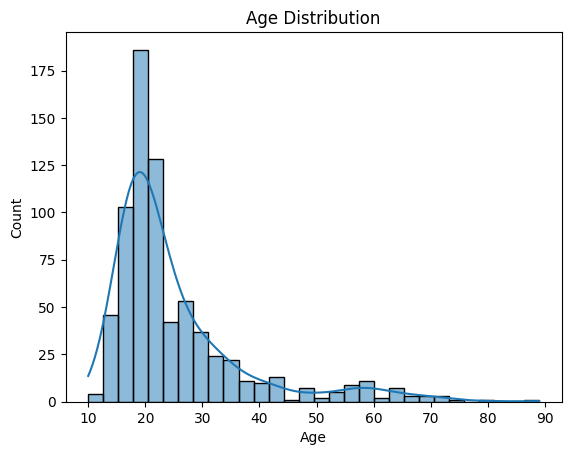

In [33]:
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

Graph shows that most people in my dataset are young, mainly around 18 to 25, with a peak near age 20. There are fewer older people, but some still exist up to higher ages.

#Creates a histogram to show how many hours per day people listen to music and how those values are distributed.

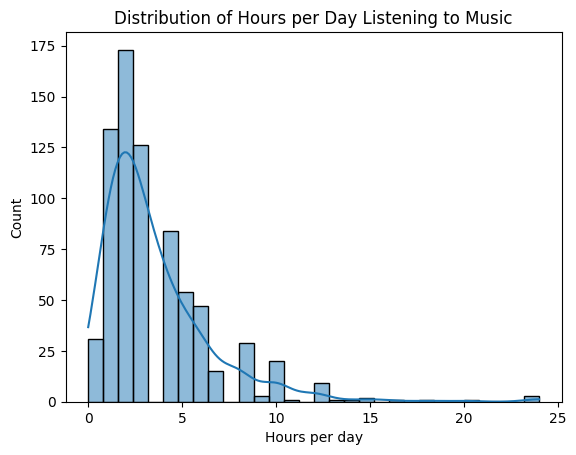

In [34]:
sns.histplot(df["Hours per day"], bins=30, kde=True)
plt.title("Distribution of Hours per Day Listening to Music")
plt.xlabel("Hours per day")
plt.ylabel("Count")
plt.show()

This graph shows that most people listen to music about 1 to 4 hours per day, with a peak around 2 - 3 hours. Only a few people listen for a very long time like over 10 hours.

#Creates a pie chart to show the percentage distribution of people's favorite music genres.

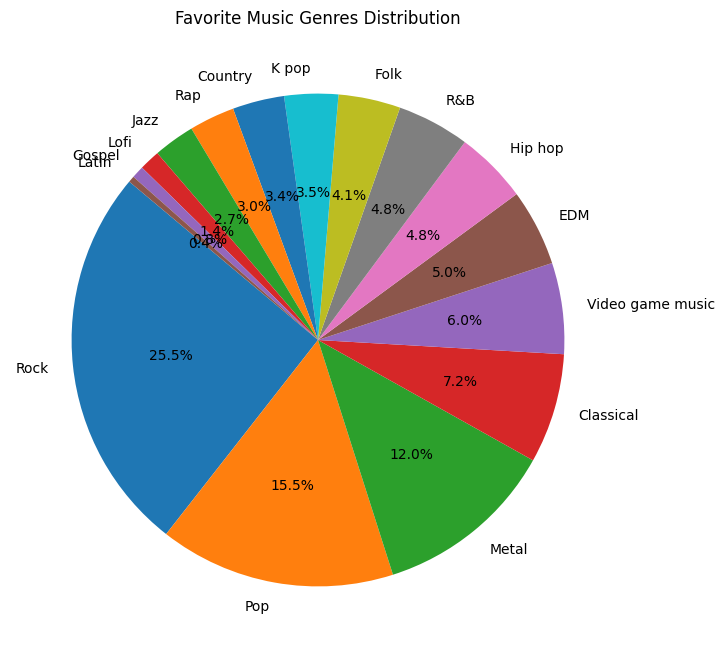

In [35]:
#count each genre
genre_counts = df["Fav genre"].value_counts()

#plot
plt.figure(figsize=(8,8))
plt.pie(
    genre_counts,
    labels=genre_counts.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Favorite Music Genres Distribution")
plt.show()

This chart shows that Rock is the most popular genre. Pop and Metal are also quite popular, but smaller than Rock.

Genres like Classical, Video game music, EDM, and Hip hop are in the middle, not too big but still common.

#Creates a bar chart showing how many people are instrumentalists vs not instrumentalists in the dataset.

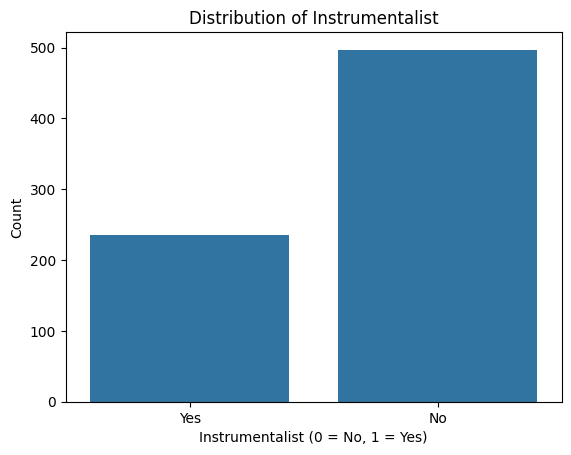

In [36]:
sns.countplot(x="Instrumentalist", data=df)

plt.title("Distribution of Instrumentalist")
plt.xlabel("Instrumentalist (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.show()

This graph shows that most people are not instrumentalists, because the “No” bar is much higher than “Yes”.

#Creates a bar chart showing how many people are composers vs not composers in the dataset.

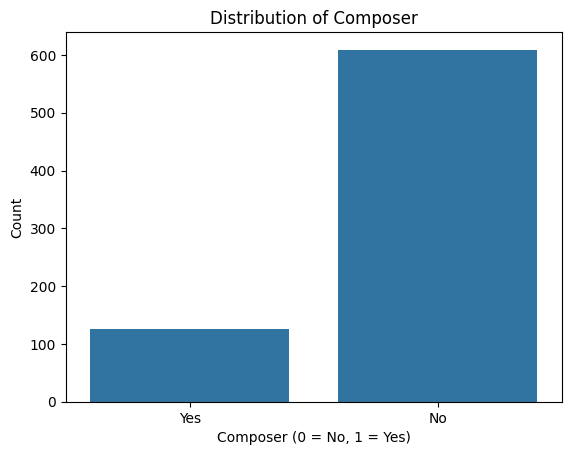

In [37]:
sns.countplot(x="Composer", data=df)

plt.title("Distribution of Composer")
plt.xlabel("Composer (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.show()

This graph shows that most people are not composer, because the “No” bar is much higher than “Yes”.

#Cleaning the dataset (filling missing values, removing unrealistic BPM values, dropping unnecessary columns.)

In [25]:
#fill missing values in Age
if "Age" in df.columns:
    df["Age"] = df["Age"].fillna(df["Age"].median())

#fill missing values in BPM
if "BPM" in df.columns:
    df["BPM"] = df["BPM"].fillna(df["BPM"].median())

#remove outliars of  BPM values
if "BPM" in df.columns:
    df = df[(df["BPM"] > 40) & (df["BPM"] < 250)]

#fill missing Yes/No values
for col in ["Composer", "Instrumentalist"]:
    if col in df.columns:
        df[col] = df[col].fillna("No")

#fill missing categorical values
for col in ["Music effects", "Fav genre", "Primary streaming service"]:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

#drop unnecessary columns
cols_to_drop = ["Primary streaming service", "Permissions", "Timestamp", "Fav genre"]
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
print(df.columns)
df.head()

Index(['Age', 'Hours per day', 'While working', 'Instrumentalist', 'Composer',
       'Exploratory', 'Foreign languages', 'BPM', 'Frequency [Classical]',
       'Frequency [Country]', 'Frequency [EDM]', 'Frequency [Folk]',
       'Frequency [Gospel]', 'Frequency [Hip hop]', 'Frequency [Jazz]',
       'Frequency [K pop]', 'Frequency [Latin]', 'Frequency [Lofi]',
       'Frequency [Metal]', 'Frequency [Pop]', 'Frequency [R&B]',
       'Frequency [Rap]', 'Frequency [Rock]', 'Frequency [Video game music]',
       'Anxiety', 'Depression', 'Insomnia', 'OCD', 'Music effects'],
      dtype='object')


,Age,Hours per day,While working,Instrumentalist,Composer,Exploratory,Foreign languages,BPM,Frequency [Classical],Frequency [Country],...,Frequency [Pop],Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects
0,18.0,3.0,Yes,Yes,Yes,Yes,Yes,156.0,Rarely,Never,...,Very frequently,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,Improve
1,63.0,1.5,Yes,No,No,Yes,No,119.0,Sometimes,Never,...,Sometimes,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,Improve
2,18.0,4.0,No,No,No,No,Yes,132.0,Never,Never,...,Rarely,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect
3,61.0,2.5,Yes,No,Yes,Yes,Yes,84.0,Sometimes,Never,...,Sometimes,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve
4,18.0,4.0,Yes,No,No,Yes,No,107.0,Never,Never,...,Sometimes,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve


Filling missing values in Age and BPM using the median (keep the data balanced.) I remove strange BPM values that are too low or too high (liar).

Handling missing Yes/No values by filling them with “No”, and for other categories you use the most common value. I dropped some columns like streaming service and favorite genre, removing things I don't need for later analysis.


#Handling missing values and converting all categorical data into numerical format (encoding).

In [26]:


#drop unnecessary columns
cols_to_drop = ["Primary streaming service", "Permissions", "Timestamp", "Fav genre"]
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

#handle missing values and outliers
if "Age" in df.columns:
    df["Age"] = df["Age"].fillna(df["Age"].median())

if "BPM" in df.columns:
    df["BPM"] = df["BPM"].fillna(df["BPM"].median())
    df.loc[(df["BPM"] < 40) | (df["BPM"] > 250), "BPM"] = np.nan
    df["BPM"] = df["BPM"].fillna(df["BPM"].median())

for col in ["Composer", "Instrumentalist"]:
    if col in df.columns:
        df[col] = df[col].fillna("No")

for col in ["Music effects", "While working", "Exploratory", "Foreign languages"]:
    if col in df.columns and df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

#remove extra spaces in text columns
object_cols = df.select_dtypes(include="object").columns
for col in object_cols:
    df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

#standardize Music effects values
if "Music effects" in df.columns:
    df["Music effects"] = df["Music effects"].replace({
        "Improve": "Improve",
        "Improved": "Improve",
        "No effect": "No effect",
        "Worsen": "Worsen",
        "Worse": "Worsen"
    })

    print("\nMusic effects before encoding:")
    print(df["Music effects"].value_counts(dropna=False))

# Check binary columns before encoding
binary_cols = [
    "While working",
    "Instrumentalist",
    "Composer",
    "Exploratory",
    "Foreign languages"
]

print("\nBefore binary encoding:")
for col in binary_cols:
    if col in df.columns:
        print(f"\n{col}")
        print(df[col].value_counts(dropna=False))

# Binary encoding
binary_map = {
    "Yes": 1, "No": 0,
    "yes": 1, "no": 0,
    "Y": 1, "N": 0,
    "True": 1, "False": 0,
    True: 1, False: 0
}

for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].replace(binary_map)

# Ordinal encoding for frequency columns
frequency_map = {
    "Never": 0,
    "Rarely": 1,
    "Sometimes": 2,
    "Often": 3,
    "Very frequently": 4,
    "Very often": 5
}

freq_cols = [col for col in df.columns if col.startswith("Frequency [")]

for col in freq_cols:
    df[col] = df[col].replace(frequency_map)

# One-hot encoding
if "Music effects" in df.columns:
    df = pd.get_dummies(df, columns=["Music effects"], drop_first=False)

# Convert boolean columns to 0/1
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

# Final check
print("\nAfter encoding:")
for col in binary_cols:
    if col in df.columns:
        print(f"\n{col}")
        print(df[col].value_counts(dropna=False))

print("\nColumns related to Music effects:")
print([col for col in df.columns if "Music effects" in col])

print("\nRemaining object columns:")
print(df.select_dtypes(include="object").columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDataFrame info:")
df.info()

df.head(10)


Music effects before encoding:
Music effects
Improve      543
No effect    167
Worsen        17
Name: count, dtype: int64

Before binary encoding:

While working
While working
Yes    576
No     151
Name: count, dtype: int64

Instrumentalist
Instrumentalist
No     495
Yes    232
Name: count, dtype: int64

Composer
Composer
No     602
Yes    125
Name: count, dtype: int64

Exploratory
Exploratory
Yes    518
No     209
Name: count, dtype: int64

Foreign languages
Foreign languages
Yes    403
No     324
Name: count, dtype: int64

After encoding:

While working
While working
1    576
0    151
Name: count, dtype: int64

Instrumentalist
Instrumentalist
0    495
1    232
Name: count, dtype: int64

Composer
Composer
0    602
1    125
Name: count, dtype: int64

Exploratory
Exploratory
1    518
0    209
Name: count, dtype: int64

Foreign languages
Foreign languages
1    403
0    324
Name: count, dtype: int64

Columns related to Music effects:
['Music effects_Improve', 'Music effects_No effect', '

/tmp/ipykernel_222/2266906715.py:70: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(binary_map)
/tmp/ipykernel_222/2266906715.py:85: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(frequency_map)


,Age,Hours per day,While working,Instrumentalist,Composer,Exploratory,Foreign languages,BPM,Frequency [Classical],Frequency [Country],...,Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects_Improve,Music effects_No effect,Music effects_Worsen
0,18.0,3.0,1,1,1,1,1,156.0,1,0,...,4,0,2,3.0,0.0,1.0,0.0,1,0,0
1,63.0,1.5,1,0,0,1,0,119.0,2,0,...,1,4,1,7.0,2.0,2.0,1.0,1,0,0
2,18.0,4.0,0,0,0,0,1,132.0,0,0,...,1,1,4,7.0,7.0,10.0,2.0,0,1,0
3,61.0,2.5,1,0,1,1,1,84.0,2,0,...,0,0,0,9.0,7.0,3.0,3.0,1,0,0
4,18.0,4.0,1,0,0,1,0,107.0,0,0,...,4,0,1,7.0,2.0,5.0,9.0,1,0,0
5,18.0,5.0,1,1,1,1,1,86.0,1,2,...,4,4,0,8.0,8.0,7.0,7.0,1,0,0
6,18.0,3.0,1,1,0,1,1,66.0,2,0,...,0,0,2,4.0,8.0,6.0,0.0,1,0,0
7,21.0,1.0,1,0,0,1,1,95.0,0,0,...,1,0,1,5.0,3.0,5.0,3.0,1,0,0
8,19.0,6.0,1,0,0,0,0,94.0,0,4,...,0,4,0,2.0,0.0,0.0,0.0,1,0,0
9,18.0,1.0,1,0,0,1,1,155.0,1,1,...,1,2,2,2.0,2.0,5.0,1.0,1,0,0


I remove useless columns, fix missing values. Then I change Yes/No and frequency into numbers, and convert categories into columns. The final data has no missing values and is ready to use for models.

For frequency: "Never": 0, "Rarely": 1, "Sometimes": 2, "Often": 3, "Very frequently": 4, "Very often": 5

#Download the clean dataset

In [27]:
df.to_csv("clean_music_data.csv", index=False)

#Remove frequency then creating a correlation heatmap.

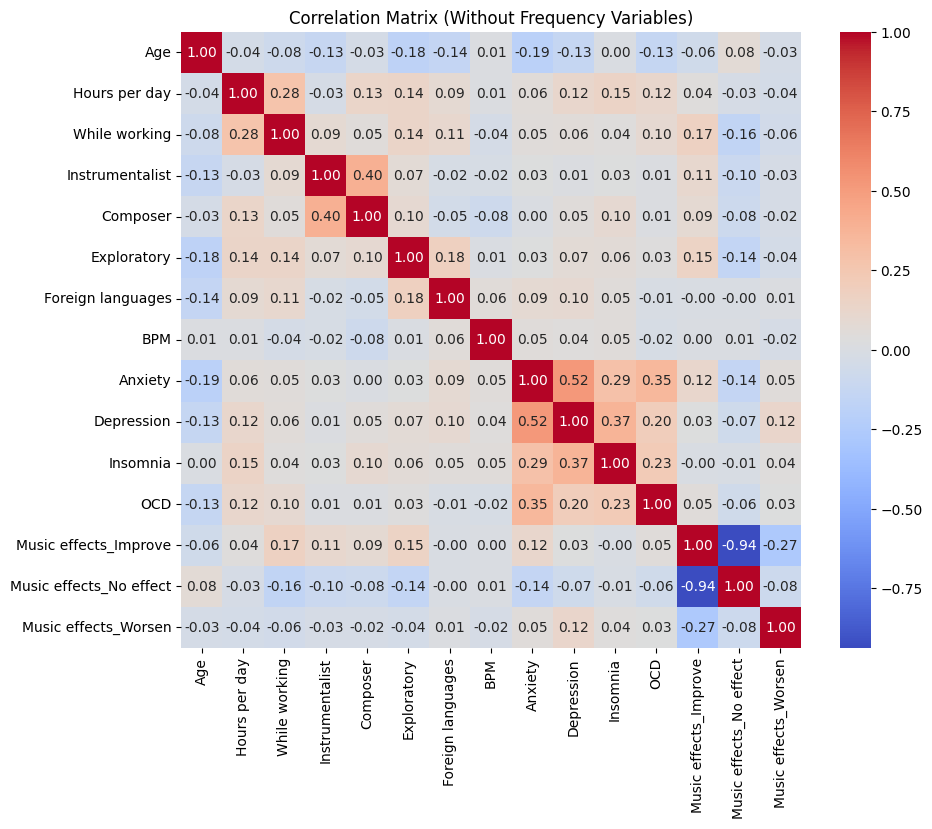

In [13]:
#remove frequency columns (make heatmap messy)
df_no_freq = df.drop(columns=[col for col in df.columns if "Frequency" in col])

#correlation matrix
corr = df_no_freq.corr(numeric_only=True)

#plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix (Without Frequency Variables)")
plt.show()

I removed the Frequency columns because there are too many of them, and they can make the graph hard to read. If I keep all of them, the heatmap will be too crowded and I cannot see the important relationships. After removing them I can focus more on the main variables like Age, Hours per day, and mental health.

Anxiety, Depression, Insomnia, and OCD are quite related to each other, because their values are positive and not small.

Hours per day has only weak relationships with mental health, so listening more music does not strongly change anxiety or depression in this data.

Age has a small negative relationship with Anxiety and Depression, so younger people may feel slightly higher levels.

For Music effects, “Improve” is strongly negative with “No effect” because they are opposite.

#Training models to predict depression level.

===== Logistic Regression =====
Accuracy: 0.6712328767123288
              precision    recall  f1-score   support

           0       0.69      0.55      0.61        69
           1       0.66      0.78      0.71        77

    accuracy                           0.67       146
   macro avg       0.68      0.66      0.66       146
weighted avg       0.67      0.67      0.67       146


===== Random Forest =====
Accuracy: 0.7191780821917808
              precision    recall  f1-score   support

           0       0.76      0.59      0.67        69
           1       0.70      0.83      0.76        77

    accuracy                           0.72       146
   macro avg       0.73      0.71      0.71       146
weighted avg       0.73      0.72      0.71       146



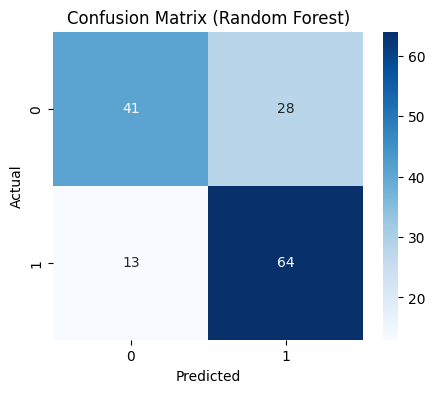


===== Top 10 Important Features =====
Anxiety                         0.151863
Insomnia                        0.104901
Age                             0.078307
BPM                             0.066686
OCD                             0.053707
Hours per day                   0.049214
Frequency [Video game music]    0.032491
Frequency [Lofi]                0.030080
Frequency [Rock]                0.029013
Frequency [Metal]               0.028569
dtype: float64


In [29]:
# Create target variable
# 0–4 = Low, 5–10 = High
df["Depression_binary"] = (df["Depression"] >= 5).astype(int)

# Prepare data
X = df.drop(columns=["Depression", "Depression_binary"])
y = df["Depression_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

# =========================
# 4. Random Forest
# =========================
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("\n===== Random Forest =====")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# =========================
# 5. Confusion Matrix
# =========================
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================
# 6. Feature Importance
# =========================
feature_importance = pd.Series(
    rf_model.feature_importances_, index=X.columns
).sort_values(ascending=False)

print("\n===== Top 10 Important Features =====")
print(feature_importance.head(10))

I think both models work okay, but Random Forest is better with about 72% accuracy compared to 67% from Logistic Regression.

The confusion matrix also shows this because it predicts 64 high depression cases. It makes more mistakes on low depression (0), since 28 are predicted wrong, but only 13 high cases are missed.

From feature importance, Anxiety, Insomnia, and Age are the most important, so mental health factors matter more than music features.

#Interim Report

In my project, I explored a few data mining strategies. I did data cleaning and preprocessing (fixing missing values and removing strange BPM values.) Then I did EDA (histograms and distributions) to let everyone easily visualize the data. I also used correlation analysis, and I think mental health variables like anxiety and depression are related, but music listening time is not strongly related.

After that, I built classification models (Logistic Regression and Random Forest). Random Forest works better (around 72% accuracy), and it shows anxiety and insomnia are more important than music features. (I think I will drop these features in the future, let's see.)

For my future work, I will try more models like KNN and SVM to see if they improve accuracy. I also want to try clustering like K-means. I may also try feature selection or tuning parameters to improve my models. I may try to do a recommendation system as well (like if people feel depressed, what kind of music I will recommend).

For what is left, I still need to finish clustering, compare all models, and write the final report and visualization. According to my plan, I still have steps like clustering analysis, result interpretation, and final report writing. I think I can finish everything on time because most of the hard parts like cleaning and modeling are already done.